# Hull Moving Average — a quantitative teardown
### Daily total-return bars · HMA(16) slope · long/flat & long/short · HAC inference · permutation placebo · SMA/MACD benchmarks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cuts false signals%3F: Busted](https://img.shields.io/badge/Cuts_false_signals%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the HMA(16)-slope timing rule beats buy-and-hold on a net, excess-of-cash basis, beats the simpler SMA(50) and MACD rules, and fires fewer false signals — across five liquid daily tapes.

> **Not investment advice.** Real data: Yahoo daily total-return bars, full history to 2026-06-12, as-of **2026-06-13**; the offline core runs the deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hull_moving_average import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-13"

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | HMA active spread vs buy&hold **-4.35 bps/day**, HAC *t* = **-5.31** (gross *t* = -5.01); permutation *p* = **1**; negative on all 5 tapes & both halves. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.089** vs buy&hold **0.646**; loses gross; long/short Sharpe **-0.545**. |
| **Cuts false signals?** | `BUSTED` | **32.5** switches/yr vs SMA **17.4** (~2×); HMA Sharpe < SMA Sharpe (0.465). |

> In plain words: the HMA does lag less, but on daily equity noise that buys more whipsaws and a lower Sharpe — the timing carries negative information.

## 1 · The claim, steelmanned

Let $\text{WMA}_n(P)_t = \sum_{i=1}^{n} i\,P_{t-n+i} / \sum_{i=1}^{n} i$ be the linearly-weighted MA. Hull (2005) defines

$$\text{HMA}_n = \text{WMA}_{\lfloor\sqrt{n}\rceil}\big(2\,\text{WMA}_{n/2}(P) - \text{WMA}_n(P)\big).$$

The trend rule: hold $d_t = +1$ when $\text{HMA}_t > \text{HMA}_{t-1}$ (rising), $0$ (or $-1$) otherwise. The hypotheses:

- **H₁ (signal).** $\mathbb{E}[\,r^{\text{strat}}_t - r^{\text{B\&H}}_t\,] > 0$ — the *active spread* (timing minus exposure) is positive.
- **H₂ (beats SMA).** Net Sharpe$(\text{HMA}) > $ Net Sharpe$(\text{SMA})$.
- **H₃ (fewer false signals).** switches/yr$(\text{HMA}) < $ switches/yr$(\text{SMA})$.

We reject **all three**: H₁ is significantly *negative* (HAC *t* = -5.31), H₂ is reversed (0.089 < 0.465), and H₃ is reversed (32.5 > 17.4 switches/yr).

## 2 · So what? — what rides on each answer

The HMA is one of the most popular 'upgrade your moving average' indicators in retail tooling, defaulted on countless TradingView charts. If H₁–H₃ held, it would be a strict Pareto improvement over the SMA — earlier turns *and* less noise — droppable into any MA strategy for free. The finding that it is *strictly worse* (lower Sharpe, more whipsaws, negative timing) matters because the indicator *feels* better: it visibly hugs price, so users mistake responsiveness for edge. This is the lag/noise trade-off made concrete.

## 3 · How we'd know — the protocol

- **Indicator.** HMA(16) (a common default); benchmarks SMA(50) and MACD(12/26/9).
- **Rule.** Long/flat: $d_t = \mathbb{1}[\text{HMA}_t > \text{HMA}_{t-1}]$ for HMA; $\mathbb{1}[C_t > \text{SMA}_{50}]$ for SMA; $\mathbb{1}[\text{MACD}>\text{signal}]$ for MACD. A long/short variant flips flat → −1.
- **Execution lag.** One `shift`: position formed on the close of $t$ earns the close-to-close return of $t+1$. Stated once, applied once.
- **Costs.** One-way × NAV on $|d_t - d_{t-1}|$ turnover; short legs pay 50 bps/yr borrow.
- **Signal test.** HAC (Newey-West) one-sample *t* on the daily *active spread* $r^{\text{strat}}-r^{\text{B\&H}}$ — excess-vs-excess by construction.
- **Placebo.** Circular-shift the realised position path 2,000× (kills timing, keeps turnover/bias); one-sided *p* on the gross spread.
- **Robustness.** Cost sweep, per-instrument, first-vs-second-half split, long/short.
- **Positive control.** Synthetic tape with a *planted* regime-switching trend.

Five tapes: SPY, QQQ, AAPL, MSFT, XLE — full history to 2026-06-12 (SPY n = 8400).

## 4 · The teardown

### 4a · HMA vs SMA vs MACD vs buy-and-hold — net Sharpe and active-spread *t*

The bar that matters is the active-spread HAC *t*: if HMA timing helps, it clears +2.

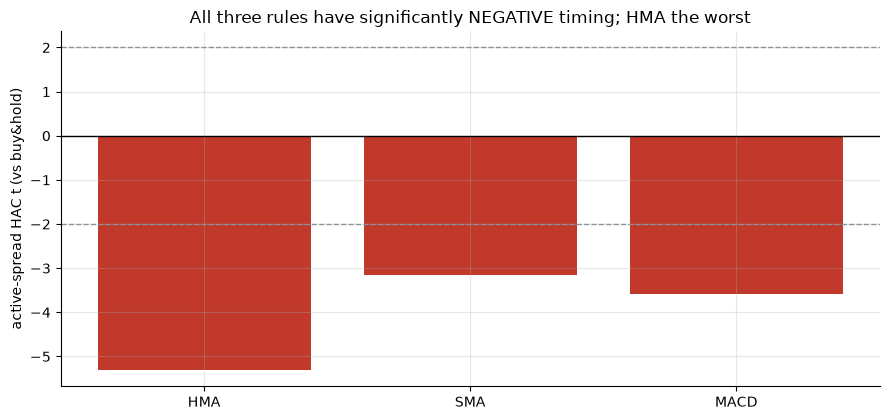

,rule,sharpe_net,spread_bps,spread_t,sw/yr
0,HMA,0.089,-4.354,-5.312,32.46
1,SMA,0.465,-2.736,-3.148,17.43
2,MACD,0.404,-2.991,-3.580,21.42
3,B&H,0.646,0.000,NaN,0.00


In [2]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), hma_period=16, sma_period=50, cost_bps=2.0)
    rows = [(k, res[k]['sharpe_net'], res[k]['mean_spread_bps'], res[k]['spread_t'],
             res[k]['switches_per_yr']) for k in ('HMA','SMA','MACD')]
    rows.append(('B&H', res['HMA']['bh_sharpe'], 0.0, float('nan'), 0.0))
    tbl = pd.DataFrame(rows, columns=['rule','sharpe_net','spread_bps','spread_t','sw/yr'])
else:
    tbl = pd.DataFrame({
        'rule': ['HMA','SMA','MACD','B&H'],
        'sharpe_net': [0.089,0.465,0.404,0.646],
        'spread_bps': [-4.35,-2.74,-2.99,0.0],
        'spread_t': [-5.31,-3.15,-3.58,float('nan')],
        'sw/yr': [32.5,17.4,21.4,0.0]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
sub = tbl[tbl['rule']!='B&H']
col = [RED if t < 0 else GREY for t in sub['spread_t']]
ax.bar(sub['rule'], sub['spread_t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (vs buy&hold)')
ax.set_title('All three rules have significantly NEGATIVE timing; HMA the worst')
plt.tight_layout(); plt.show()
tbl.round(3)

> In plain words: every timing rule's active spread is significantly negative — none beats holding. HMA is the worst (*t* = -5.31), below the plain SMA (*t* = -3.15). The fancy indicator loses to the simple one **and** to holding.

### 4b · The whipsaw count — the 'fewer false signals' claim, head to head

Position changes per year. The folk claim says HMA < SMA.

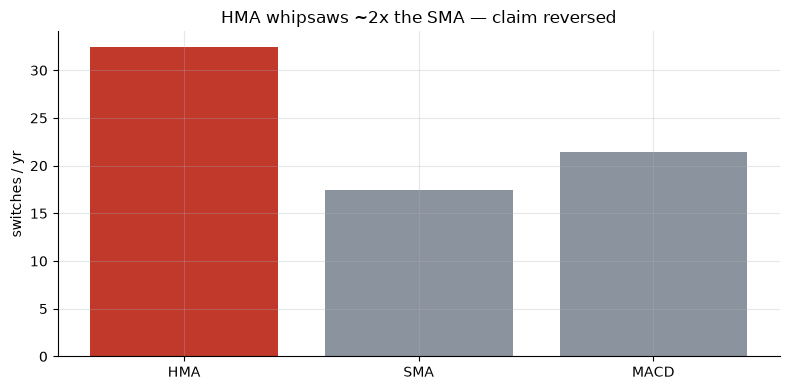

HMA/SMA switch ratio: 1.86x


In [3]:
if HAVE_REAL:
    sw = {k: res[k]['switches_per_yr'] for k in ('HMA','SMA','MACD')}
else:
    sw = dict(HMA=32.5, SMA=17.4, MACD=21.4)
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['HMA','SMA','MACD'], [sw['HMA'],sw['SMA'],sw['MACD']],
       color=[RED, GREY, GREY])
ax.set_ylabel('switches / yr'); ax.set_title('HMA whipsaws ~2x the SMA — claim reversed')
plt.tight_layout(); plt.show()
print(f"HMA/SMA switch ratio: {sw['HMA']/sw['SMA']:.2f}x")

> In plain words: 32.5 vs 17.4 switches/yr. Lower lag = faster reaction = more reaction to noise. The HMA's defining selling point is false on the tape.

### 4c · Permutation placebo — timing vs exposure

Circularly shift the realised position path 2,000×; the statistic is the gross active spread. If the timing is informative, the real spread beats the placebo distribution.

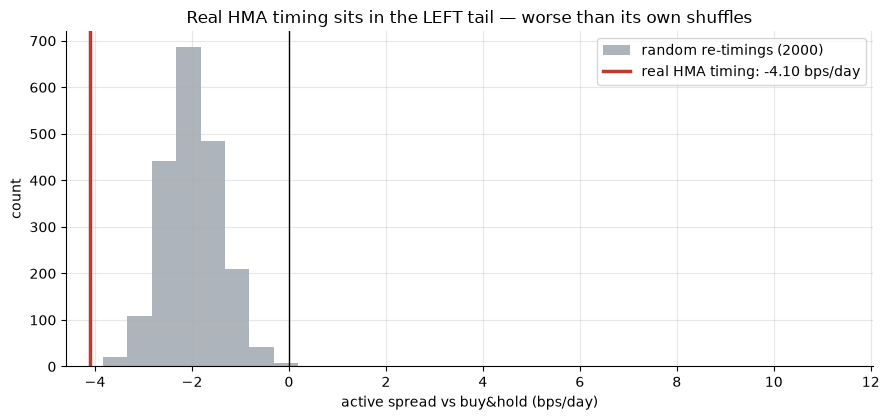

observed -4.10 | placebo mean -1.99 | one-sided p = 1.000


In [4]:
if HAVE_REAL:
    p = st.permutation_pvalue(tape('SPY')['close'].pct_change(),
                              st.hma_position(tape('SPY')['close'], 16),
                              cost_bps=0.0, n_perm=2000, seed=432)
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
    import numpy as _np
    rng = _np.random.default_rng(432)
    a = tape('SPY')['close'].pct_change().fillna(0).to_numpy()
    held = st.hma_position(tape('SPY')['close'],16).shift(1).fillna(0).to_numpy()
    draws = []
    for _ in range(2000):
        h = _np.roll(held, int(rng.integers(1,len(held))))
        turn=_np.abs(_np.diff(h,prepend=0.0)); draws.append(((h*a-turn*0)-a).mean()*1e4)
else:
    obs, plac, pv = -4.1, -1.99, 1.0
    import numpy as _np
    draws = list(_np.random.default_rng(1).normal(-1.99, 0.6, 2000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.7, label='random re-timings (2000)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real HMA timing: {obs:+.2f} bps/day')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('active spread vs buy&hold (bps/day)'); ax.set_ylabel('count')
ax.set_title('Real HMA timing sits in the LEFT tail — worse than its own shuffles')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} | placebo mean {plac:+.2f} | one-sided p = {pv:.3f}')

> In plain words: *p* = 1 — essentially every random re-timing of the HMA's own trades beats the real ones. The timing isn't just uninformative; it is reliably on the wrong side.

### 4d · Per-instrument & in/out-of-sample — is it ever positive?

Active-spread *t* on all five tapes, and the SPY first-vs-second-half split.

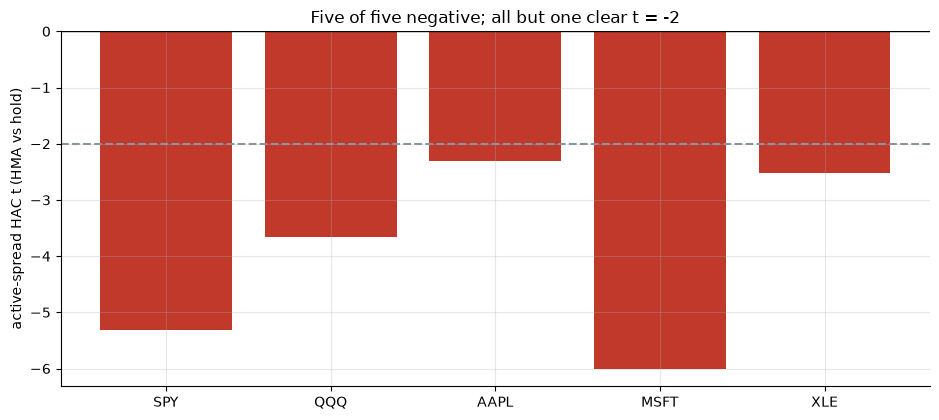

SPY split  H1 t = -3.81 | H2 t = -3.71  (both negative)


,ticker,hma_sharpe,bh_sharpe,spread_bps,t
0,SPY,0.089,0.646,-4.354,-5.312
1,QQQ,0.107,0.519,-4.818,-3.660
2,AAPL,0.580,0.624,-4.108,-2.310
3,MSFT,0.372,0.825,-7.490,-6.017
4,XLE,0.148,0.438,-3.870,-2.517


In [5]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        r = st.run_experiment(tape(t), cost_bps=2.0)['HMA']
        recs.append((t, r['sharpe_net'], r['bh_sharpe'], r['mean_spread_bps'], r['spread_t']))
    per = pd.DataFrame(recs, columns=['ticker','hma_sharpe','bh_sharpe','spread_bps','t'])
    spy = tape('SPY'); half = len(spy)//2
    h1 = st.run_experiment(spy.iloc[:half], cost_bps=2.0)['HMA']
    h2 = st.run_experiment(spy.iloc[half:], cost_bps=2.0)['HMA']
    split = [(h1['spread_t'], h2['spread_t'])]
else:
    per = pd.DataFrame({'ticker': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'hma_sharpe': [0.089, 0.107, 0.58, 0.372, 0.148], 'bh_sharpe': [0.646, 0.519, 0.624, 0.825, 0.438], 'spread_bps': [-4.35, -4.82, -4.11, -7.49, -3.87], 't': [-5.31, -3.66, -2.31, -6.02, -2.52]})
    split = [(-3.81, -3.71)]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(per['ticker'], per['t'], color=RED)
ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (HMA vs hold)')
ax.set_title('Five of five negative; all but one clear t = -2')
plt.tight_layout(); plt.show()
print('SPY split  H1 t = %.2f | H2 t = %.2f  (both negative)' % split[0])
per.round(3)

> In plain words: every instrument's HMA timing trails buy-and-hold, and SPY loses in both halves (H1 *t* = -3.81, H2 *t* = -3.71). Not a one-regime artefact.

## 5 · The verdict

- **Signal `NONE`** — active spread -4.35 bps/day, HAC *t* -5.31 (gross -5.01); permutation *p* = 1; negative on 5/5 tapes and both halves.
- **Tradability `MIRAGE`** — net Sharpe 0.089 vs hold 0.646; loses gross; long/short Sharpe -0.545, spread -8.78 bps/day (*t* -5.36).
- **Cuts false signals? `BUSTED`** — 32.5 vs 17.4 switches/yr; HMA Sharpe below the simpler SMA.

## 6 · Could you trade it? — the cost landscape

The spread is below zero before costs; there is no break-even, and the long/short version compounds the loss:

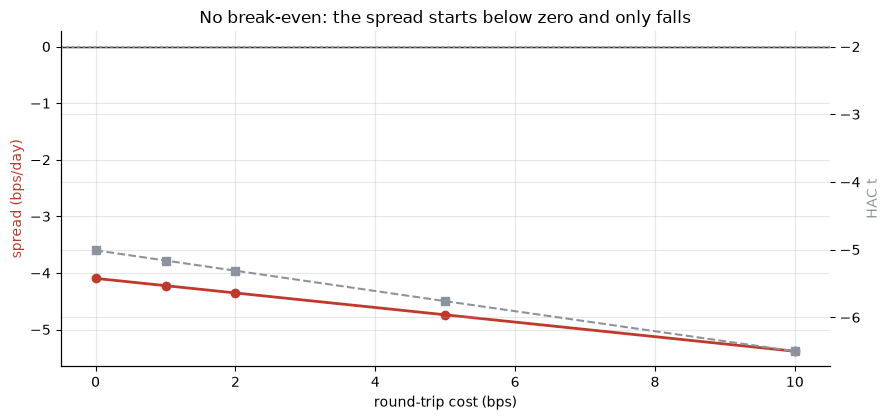

long/short net Sharpe: -0.545 (worse than long/flat)


In [6]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), cost_bps=c)['HMA']['mean_spread_bps'] for c in costs]
    tst = [st.run_experiment(tape('SPY'), cost_bps=c)['HMA']['spread_t'] for c in costs]
    lsr = st.run_experiment(tape('SPY'), cost_bps=2.0, long_short=True)['HMA']
    ls_sh = lsr['sharpe_net']
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]; spr = [-4.1, -4.23, -4.35, -4.74, -5.38]; tst = [-5.01, -5.16, -5.31, -5.76, -6.5]
    ls_sh = -0.545
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2, label='active spread (bps/day)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('spread (bps/day)', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('No break-even: the spread starts below zero and only falls')
plt.tight_layout(); plt.show()
print(f'long/short net Sharpe: {ls_sh:+.3f} (worse than long/flat)')

## 7 · Going further — the positive control

Is the *engine* able to find a trend, or is it always negative? Plant a persistent regime-switching trend in a synthetic tape and sweep the knob:

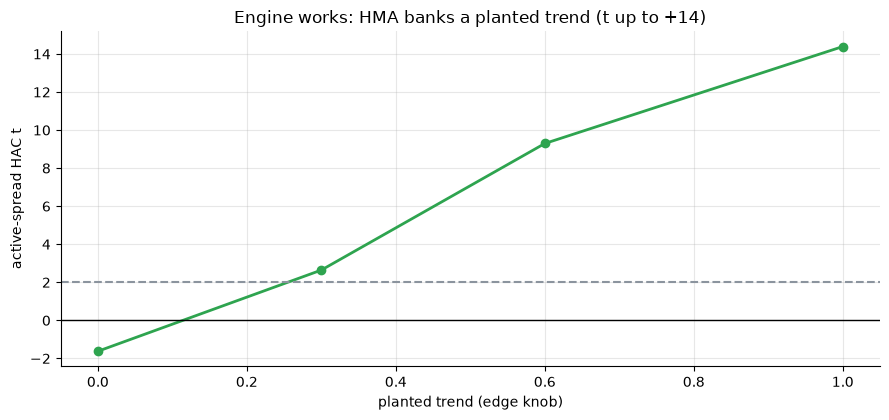

edge=0 t=-1.62 (≈null) ; edge=0.3 t=2.64 ; edge=1.0 t=14.39


In [7]:
edges = [0.0, 0.3, 0.6, 1.0]
if HAVE_REAL or True:
    sp, tt = [], []
    for e in edges:
        b, _ = data.synthetic_panel(n_days=4000, edge=e, seed=432)
        r = st.run_experiment(b, cost_bps=0.0)['HMA']
        sp.append(r['mean_spread_bps']); tt.append(r['spread_t'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(edges, tt, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted trend (edge knob)'); ax.set_ylabel('active-spread HAC t')
ax.set_title('Engine works: HMA banks a planted trend (t up to +14)')
plt.tight_layout(); plt.show()
print('edge=0 t=%.2f (≈null) ; edge=0.3 t=%.2f ; edge=1.0 t=%.2f' % (tt[0], tt[1], tt[-1]))

The engine is a faithful trend detector: plant a real persistent trend and the HMA rule banks it, clearing *t* = 2 by `edge = 0.3` and reaching *t* ≈ +14 at `edge = 1.0`; with no trend planted it reads ≈ 0 (slightly negative from turnover drag). The real-tape verdict is therefore a statement about the **market** — daily US equity returns are too noisy at the scale the HMA reacts to — not a broken harness. Forks worth trying: weekly bars, a much slower HMA, or trend-prone futures (where time-series momentum is documented) rather than a single equity index.